# Assignment 4 – Tree & Graph Visualization

---

## Dataset Descriptions

### 1. Tree Dataset – Animal Kingdom (`class.csv`)
**Source:** UCI Machine Learning Repository – Zoo Animal Classification dataset.  
**Structure:**
- **Nodes:** The root node is `'Animal Kingdom'`. The 7 class nodes (Mammal, Bird, Reptile, Fish, Amphibian, Bug, Invertebrate) are children of the root. Individual animal species are leaf nodes beneath their respective class.
- **Edges:** An edge exists from `Animal Kingdom → Class` and from `Class → Animal Species`, representing the biological classification hierarchy.
- **Why ideal for tree?** The data has a clear parent–child hierarchy with no cycles, making it a perfect tree structure.

### 2. Graph Dataset – Global Stocks Traded (`stocks_traded_total_value.csv`)
**Source:** World Bank – Stocks traded, total value (USD).  
**Structure:**
- **Nodes:** Countries / economic regions (e.g., USA, Australia, Arab World).
- **Edges:** An edge is drawn between two countries if their most recent annual stock trading volumes fall within a similar order of magnitude (ratio < 5×), representing economic similarity in market activity.
- **Why ideal for graph?** Countries form a network with many-to-many relationships based on comparable trading volumes — not a strict hierarchy — making it a true general graph.

---

## Setup – Install & Import Libraries

In [1]:
# Install required packages if not already installed
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'networkx', 'matplotlib',
                'pandas', 'numpy', 'pyvis'], capture_output=True)

CompletedProcess(args=['/opt/miniconda3/bin/python', '-m', 'pip', 'install', 'networkx', 'matplotlib', 'pandas', 'numpy', 'pyvis'], returncode=0, stdout=b'Requirement already satisfied: networkx in /opt/miniconda3/lib/python3.12/site-packages (3.5)\nRequirement already satisfied: matplotlib in /opt/miniconda3/lib/python3.12/site-packages (3.10.8)\nRequirement already satisfied: pandas in /opt/miniconda3/lib/python3.12/site-packages (2.3.3)\nRequirement already satisfied: numpy in /opt/miniconda3/lib/python3.12/site-packages (1.26.4)\nCollecting pyvis\n  Downloading pyvis-0.3.2-py3-none-any.whl.metadata (1.7 kB)\nRequirement already satisfied: contourpy>=1.0.1 in /opt/miniconda3/lib/python3.12/site-packages (from matplotlib) (1.3.0)\nRequirement already satisfied: cycler>=0.10 in /opt/miniconda3/lib/python3.12/site-packages (from matplotlib) (0.12.1)\nRequirement already satisfied: fonttools>=4.22.0 in /opt/miniconda3/lib/python3.12/site-packages (from matplotlib) (4.54.1)\nRequirement 

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from collections import defaultdict

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully.')

All libraries imported successfully.


---
# PART 1 – Tree Visualization (`class.csv`)

## 1.1 Load & Explore the Dataset

In [7]:
# Load the animal class dataset
df_animal = pd.read_csv('/Users/zainwajid/Desktop/Parhai/DS 351 Data Visualisation/Assignments/4/class.csv')
print('Shape:', df_animal.shape)
display(df_animal)

Shape: (7, 4)


,Class_Number,Number_Of_Animal_Species_In_Class,Class_Type,Animal_Names
0,1,41,Mammal,"aardvark, antelope, bear, boar, buffalo, calf,..."
1,2,20,Bird,"chicken, crow, dove, duck, flamingo, gull, haw..."
2,3,5,Reptile,"pitviper, seasnake, slowworm, tortoise, tuatara"
3,4,13,Fish,"bass, carp, catfish, chub, dogfish, haddock, h..."
4,5,4,Amphibian,"frog, frog, newt, toad"
5,6,8,Bug,"flea, gnat, honeybee, housefly, ladybird, moth..."
6,7,10,Invertebrate,"clam, crab, crayfish, lobster, octopus, scorpi..."


## 1.2 Build the Tree (NetworkX DiGraph)

In [8]:
# Create a directed tree: Animal Kingdom -> Class -> Individual Animals
T = nx.DiGraph()
root = 'Animal\nKingdom'
T.add_node(root)

# Colour palette – one colour per class
CLASS_COLORS = {
    'Mammal':       '#4E79A7',
    'Bird':         '#F28E2B',
    'Reptile':      '#59A14F',
    'Fish':         '#E15759',
    'Amphibian':    '#76B7B2',
    'Bug':          '#EDC948',
    'Invertebrate': '#B07AA1',
}

node_color_map = {root: '#2C2C2C'}   # root is dark grey
node_size_map  = {root: 2800}

for _, row in df_animal.iterrows():
    class_name = row['Class_Type']
    animals    = [a.strip() for a in row['Animal_Names'].split(',')]

    # Add class node
    T.add_node(class_name)
    T.add_edge(root, class_name)
    node_color_map[class_name] = CLASS_COLORS.get(class_name, '#AAAAAA')
    node_size_map[class_name]  = 1600

    # Add animal leaf nodes
    for animal in animals:
        # make label unique if animal appears in multiple classes
        label = animal
        if label in T.nodes and T.nodes[label].get('class') != class_name:
            label = f'{animal}\n({class_name[:3]})'
        T.add_node(label, **{'class': class_name})
        T.add_edge(class_name, label)
        node_color_map[label] = CLASS_COLORS.get(class_name, '#AAAAAA') + '88'  # semi-transparent
        node_size_map[label]  = 350

print(f'Tree has {T.number_of_nodes()} nodes and {T.number_of_edges()} edges.')
print('Is a tree:', nx.is_tree(T))

Tree has 108 nodes and 107 edges.
Is a tree: True


## 1.3 Helper – Hierarchical (Top-Down) Layout

In [9]:
def hierarchy_pos(G, root, width=1.0, vert_gap=0.2, vert_loc=0, xcenter=0.5):
    """
    Compute top-down hierarchical positions for a directed tree.
    Adapted from Joel's Stack Overflow answer.
    """
    def _recurse(G, node, left, right, vert_loc, pos):
        children = list(G.successors(node))
        pos[node] = ((left + right) / 2, vert_loc)
        if children:
            dx = (right - left) / len(children)
            nextx = left
            for child in children:
                _recurse(G, child, nextx, nextx + dx, vert_loc - vert_gap, pos)
                nextx += dx
        return pos

    return _recurse(G, root, 0, width, vert_loc, {})

## 1.4 Tree Layout 1 – Hierarchical (Top-Down) Layout

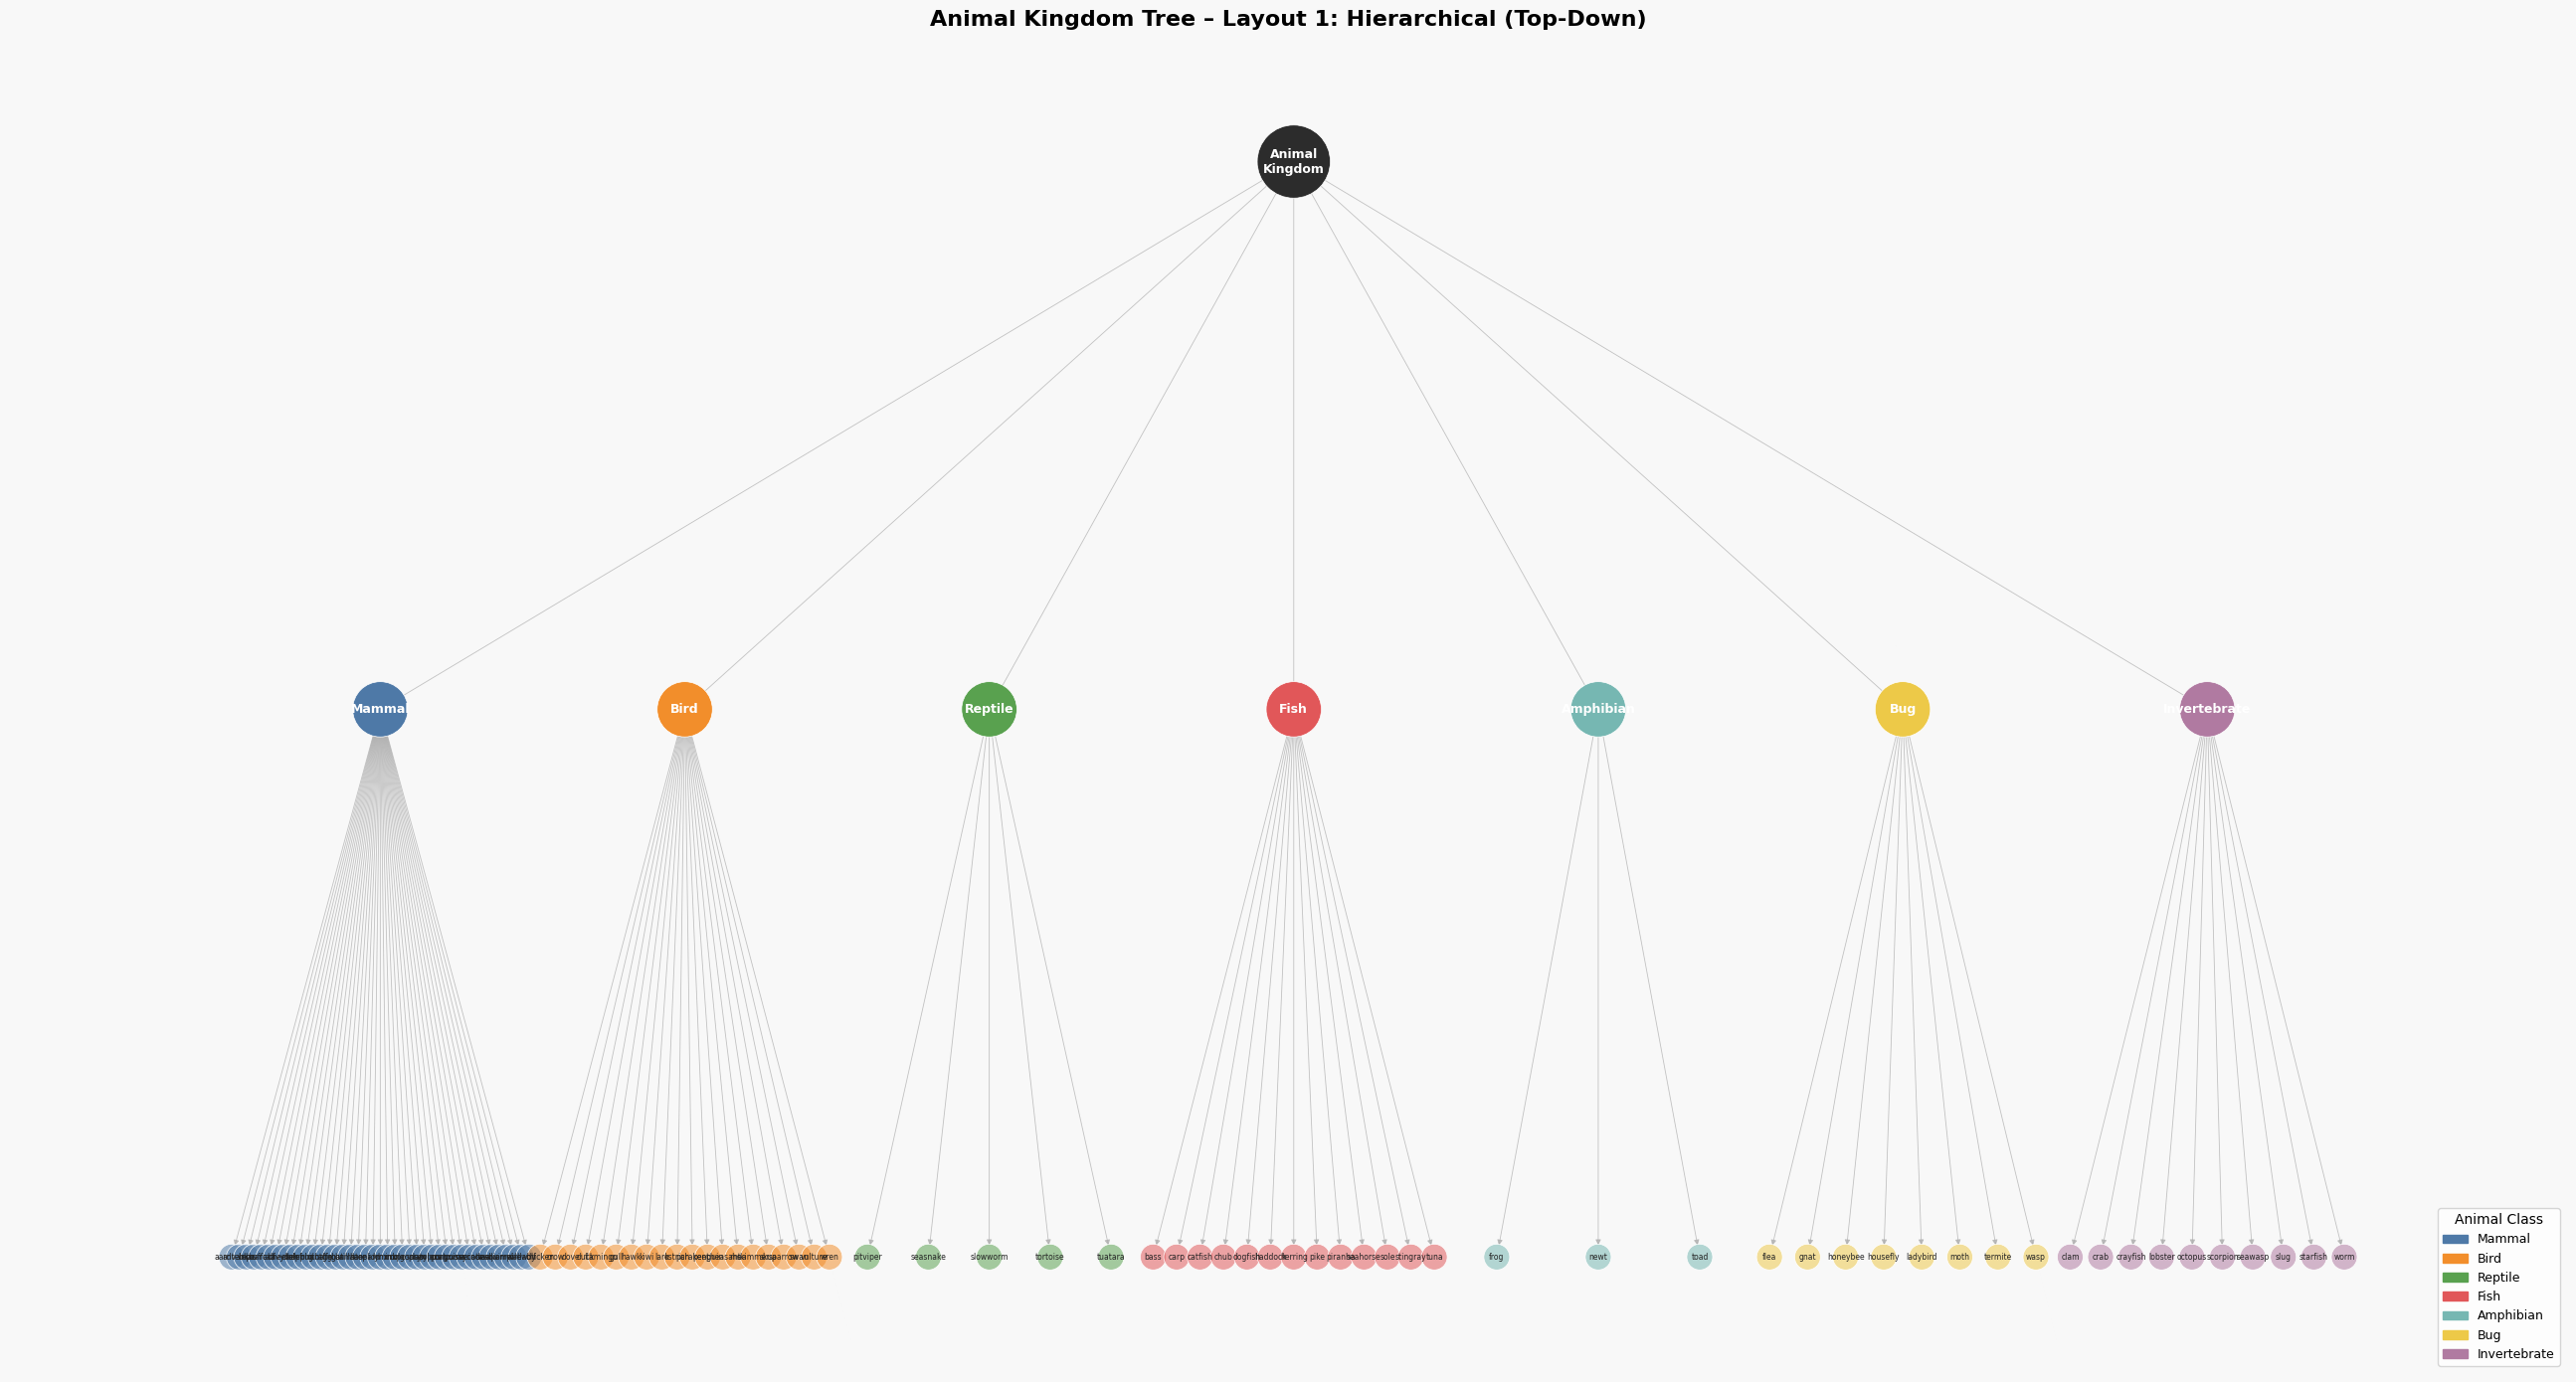

Saved: tree_layout1_hierarchical.png


In [10]:
fig, ax = plt.subplots(figsize=(26, 14))
ax.set_facecolor('#F8F8F8')
fig.patch.set_facecolor('#F8F8F8')

pos_hier = hierarchy_pos(T, root, width=2.5, vert_gap=0.3)

nodes     = list(T.nodes())
colors    = [node_color_map.get(n, '#CCCCCC') for n in nodes]
sizes     = [node_size_map.get(n, 300) for n in nodes]

nx.draw_networkx_edges(T, pos_hier, ax=ax,
                       edge_color='#AAAAAA', arrows=True,
                       arrowsize=8, width=0.6, alpha=0.7)

nx.draw_networkx_nodes(T, pos_hier, ax=ax,
                       node_color=colors, node_size=sizes,
                       edgecolors='white', linewidths=0.5)

# Only label root + class nodes (leaf labels get crowded)
class_labels = {n: n for n in [root] + list(CLASS_COLORS.keys())}
leaf_labels  = {n: n for n in nodes if n not in class_labels}

nx.draw_networkx_labels(T, pos_hier, labels=class_labels, ax=ax,
                        font_size=9, font_weight='bold', font_color='white')
nx.draw_networkx_labels(T, pos_hier, labels=leaf_labels, ax=ax,
                        font_size=5.5, font_color='#222222')

# Legend
legend_patches = [mpatches.Patch(color=c, label=cl) for cl, c in CLASS_COLORS.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9,
          title='Animal Class', title_fontsize=10)

ax.set_title('Animal Kingdom Tree – Layout 1: Hierarchical (Top-Down)',
             fontsize=16, fontweight='bold', pad=15)
ax.axis('off')
plt.tight_layout()
plt.savefig('tree_layout1_hierarchical.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: tree_layout1_hierarchical.png')

## 1.5 Tree Layout 2 – Radial (Circular) Layout

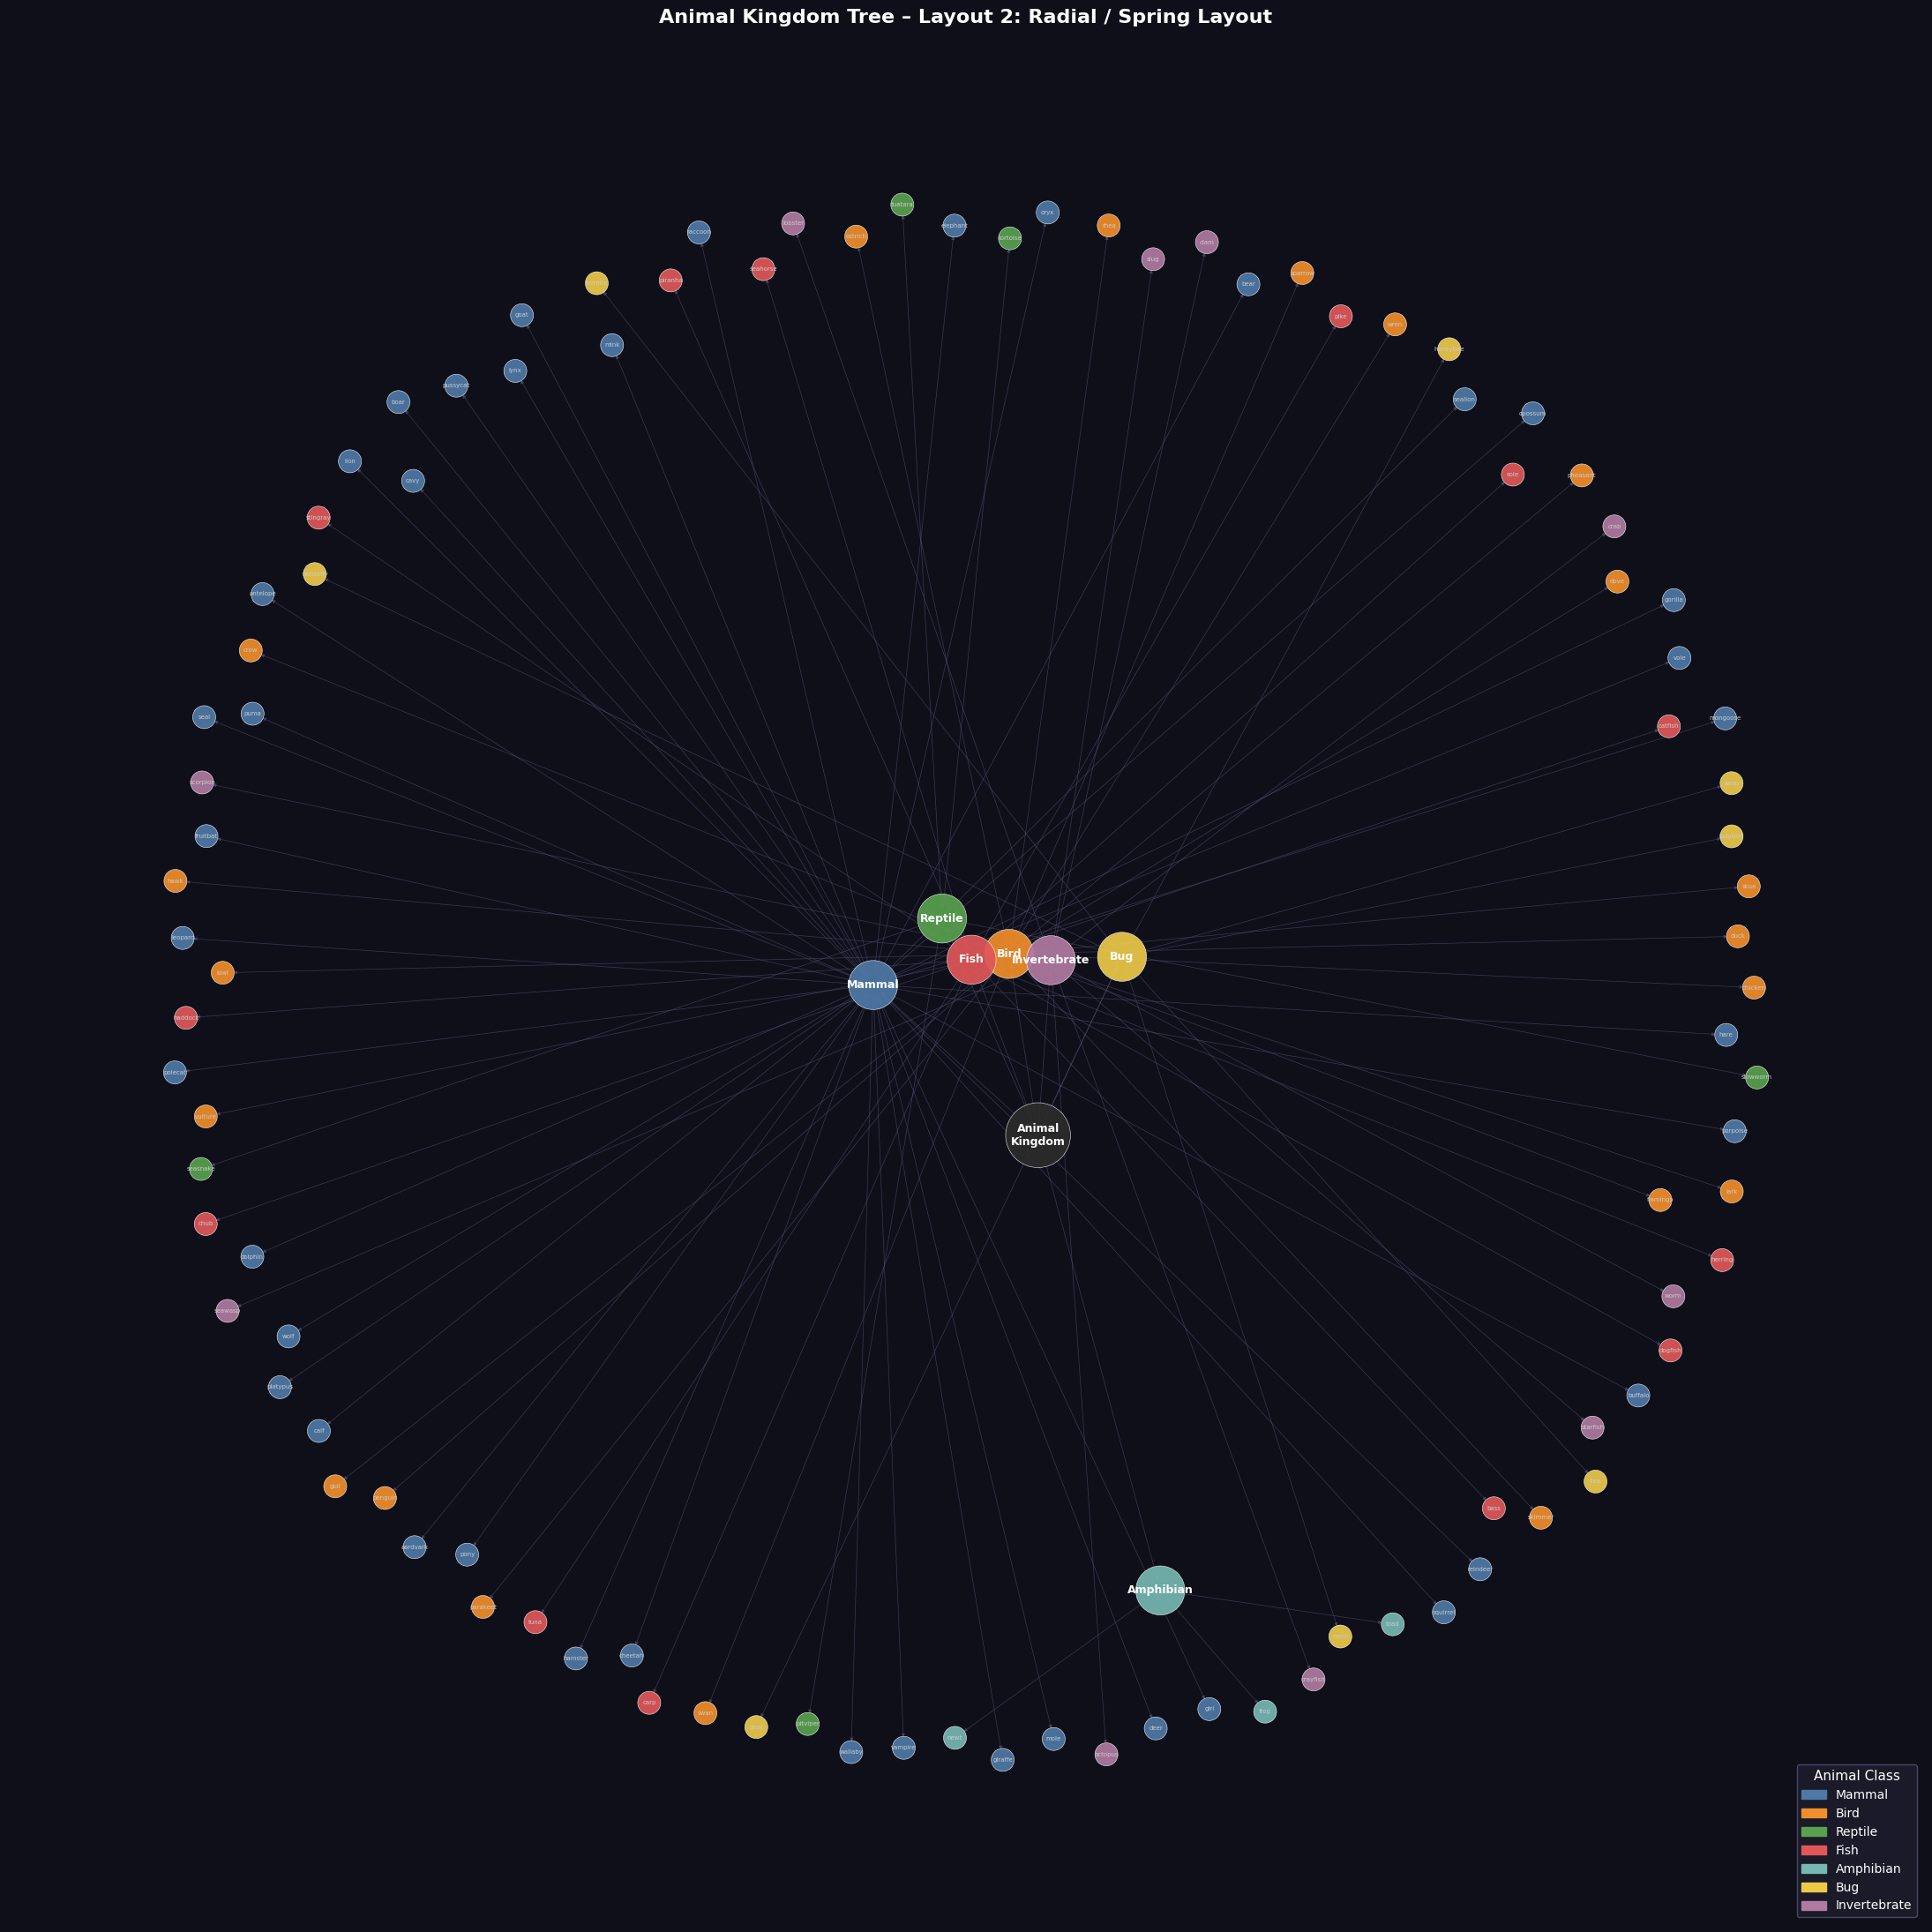

Saved: tree_layout2_radial.png


In [11]:
fig, ax = plt.subplots(figsize=(22, 22))
ax.set_facecolor('#0F0F1A')
fig.patch.set_facecolor('#0F0F1A')

# Use spring layout seeded for reproducibility – gives radial feel
pos_radial = nx.spring_layout(T, seed=42, k=0.35, iterations=120)

# Draw edges
nx.draw_networkx_edges(T, pos_radial, ax=ax,
                       edge_color='#555577', arrows=True,
                       arrowsize=6, width=0.5, alpha=0.6)

# Draw nodes
nx.draw_networkx_nodes(T, pos_radial, ax=ax,
                       node_color=colors, node_size=sizes,
                       edgecolors='#FFFFFF', linewidths=0.4, alpha=0.92)

# Labels for class + root nodes
nx.draw_networkx_labels(T, pos_radial, labels=class_labels, ax=ax,
                        font_size=9, font_weight='bold', font_color='white')
nx.draw_networkx_labels(T, pos_radial, labels=leaf_labels, ax=ax,
                        font_size=5, font_color='#CCCCCC')

# Legend
legend_patches_dark = [mpatches.Patch(color=c, label=cl) for cl, c in CLASS_COLORS.items()]
leg = ax.legend(handles=legend_patches_dark, loc='lower right', fontsize=10,
                title='Animal Class', title_fontsize=11,
                facecolor='#1E1E2E', edgecolor='#555577', labelcolor='white')
leg.get_title().set_color('white')

ax.set_title('Animal Kingdom Tree – Layout 2: Radial / Spring Layout',
             fontsize=16, fontweight='bold', color='white', pad=15)
ax.axis('off')
plt.tight_layout()
plt.savefig('tree_layout2_radial.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Saved: tree_layout2_radial.png')

---
# PART 2 – Graph Visualization (`stocks_traded_total_value.csv`)

## 2.1 Load & Explore the Dataset

In [12]:
df_stocks = pd.read_csv('/Users/zainwajid/Desktop/Parhai/DS 351 Data Visualisation/Assignments/4/stocks_traded_total_value.csv')
print('Shape:', df_stocks.shape)
display(df_stocks.head(10))
print('\nUnique countries/regions:', df_stocks['Country Name'].nunique())
print('Year range:', df_stocks['Year'].min(), '–', df_stocks['Year'].max())

Shape: (4080, 4)


,Country Name,Year,Value (USD),Status
0,Arab World,2006,1.585737e+12,Normal value
1,Arab World,2010,3.069249e+11,Normal value
2,Arab World,2011,3.792060e+11,Normal value
3,Arab World,2012,5.984638e+11,Normal value
4,Arab World,2014,8.071476e+11,Normal value
5,Arab World,2015,5.714971e+11,Normal value
6,Arab World,2016,3.947872e+11,Normal value
7,Arab World,2017,3.058989e+11,Normal value
8,Arab World,2018,2.991878e+11,Normal value
9,Arab World,2019,2.861235e+11,Normal value



Unique countries/regions: 146
Year range: 1975 – 2024


## 2.2 Build the Graph

In [13]:
# --- Select a focused, representative subset of countries ---
SELECTED = [
    'United States', 'China', 'Japan', 'United Kingdom',
    'Germany', 'France', 'India', 'Canada',
    'Australia', 'Brazil', 'South Korea', 'Hong Kong SAR, China',
    'Singapore', 'Switzerland', 'Saudi Arabia', 'South Africa',
    'Argentina', 'Austria', 'Vietnam', 'Pakistan'
]

# Latest available value per country
latest = (
    df_stocks[df_stocks['Country Name'].isin(SELECTED)]
    .sort_values('Year', ascending=False)
    .groupby('Country Name')['Value (USD)']
    .first()
    .dropna()
)

print('Countries with data:', len(latest))
print(latest.sort_values(ascending=False).to_string())

Countries with data: 19
Country Name
United States           4.260021e+13
China                   3.487367e+13
Japan                   7.384575e+12
India                   3.347429e+12
Hong Kong SAR, China    2.996539e+12
Canada                  2.149980e+12
France                  1.328364e+12
Germany                 9.239980e+11
Brazil                  9.096552e+11
Australia               8.452722e+11
Switzerland             7.193488e+11
United Kingdom          6.368180e+11
Saudi Arabia            4.740476e+11
South Africa            1.920280e+11
Vietnam                 1.604068e+11
Singapore               1.142042e+11
Austria                 3.020403e+10
Pakistan                1.983186e+10
Argentina               1.158650e+09


In [14]:
# Build an undirected graph.
# Edge rule: connect two countries if their trading volumes are within a
# 5× ratio of each other (same order-of-magnitude economic scale).

G = nx.Graph()
countries = latest.index.tolist()

for c in countries:
    G.add_node(c, value=latest[c])

RATIO_THRESHOLD = 5.0
for i, c1 in enumerate(countries):
    for c2 in countries[i+1:]:
        v1, v2 = latest[c1], latest[c2]
        if v1 > 0 and v2 > 0:
            ratio = max(v1, v2) / min(v1, v2)
            if ratio <= RATIO_THRESHOLD:
                G.add_edge(c1, c2, weight=1 / ratio)  # stronger edge = closer values

print(f'Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
print('Is connected:', nx.is_connected(G))

Graph: 19 nodes, 62 edges
Is connected: False


## 2.3 Assign Visual Properties

In [15]:
# Node size proportional to log(trading_value)
vals       = np.array([latest.get(n, 1) for n in G.nodes()])
log_vals   = np.log10(np.maximum(vals, 1))
node_sizes = ((log_vals - log_vals.min()) / (log_vals.max() - log_vals.min() + 1e-9)) * 2000 + 400

# Colour by continent (manual mapping for the selected countries)
CONTINENT = {
    'United States': 'Americas', 'Canada': 'Americas',
    'Brazil': 'Americas', 'Argentina': 'Americas',
    'United Kingdom': 'Europe', 'Germany': 'Europe',
    'France': 'Europe', 'Austria': 'Europe', 'Switzerland': 'Europe',
    'China': 'Asia', 'Japan': 'Asia', 'India': 'Asia',
    'South Korea': 'Asia', 'Hong Kong SAR, China': 'Asia',
    'Singapore': 'Asia', 'Vietnam': 'Asia', 'Pakistan': 'Asia',
    'Saudi Arabia': 'Middle East',
    'Australia': 'Oceania',
    'South Africa': 'Africa',
}
CONT_COLOR = {
    'Americas':    '#E15759',
    'Europe':      '#4E79A7',
    'Asia':        '#59A14F',
    'Middle East': '#EDC948',
    'Oceania':     '#76B7B2',
    'Africa':      '#B07AA1',
}
node_colors_g = [CONT_COLOR.get(CONTINENT.get(n, 'Other'), '#AAAAAA') for n in G.nodes()]

# Edge weights for drawing
edge_weights = [G[u][v]['weight'] * 3 for u, v in G.edges()]

## 2.4 Graph Layout 1 – Spring (Force-Directed) Layout

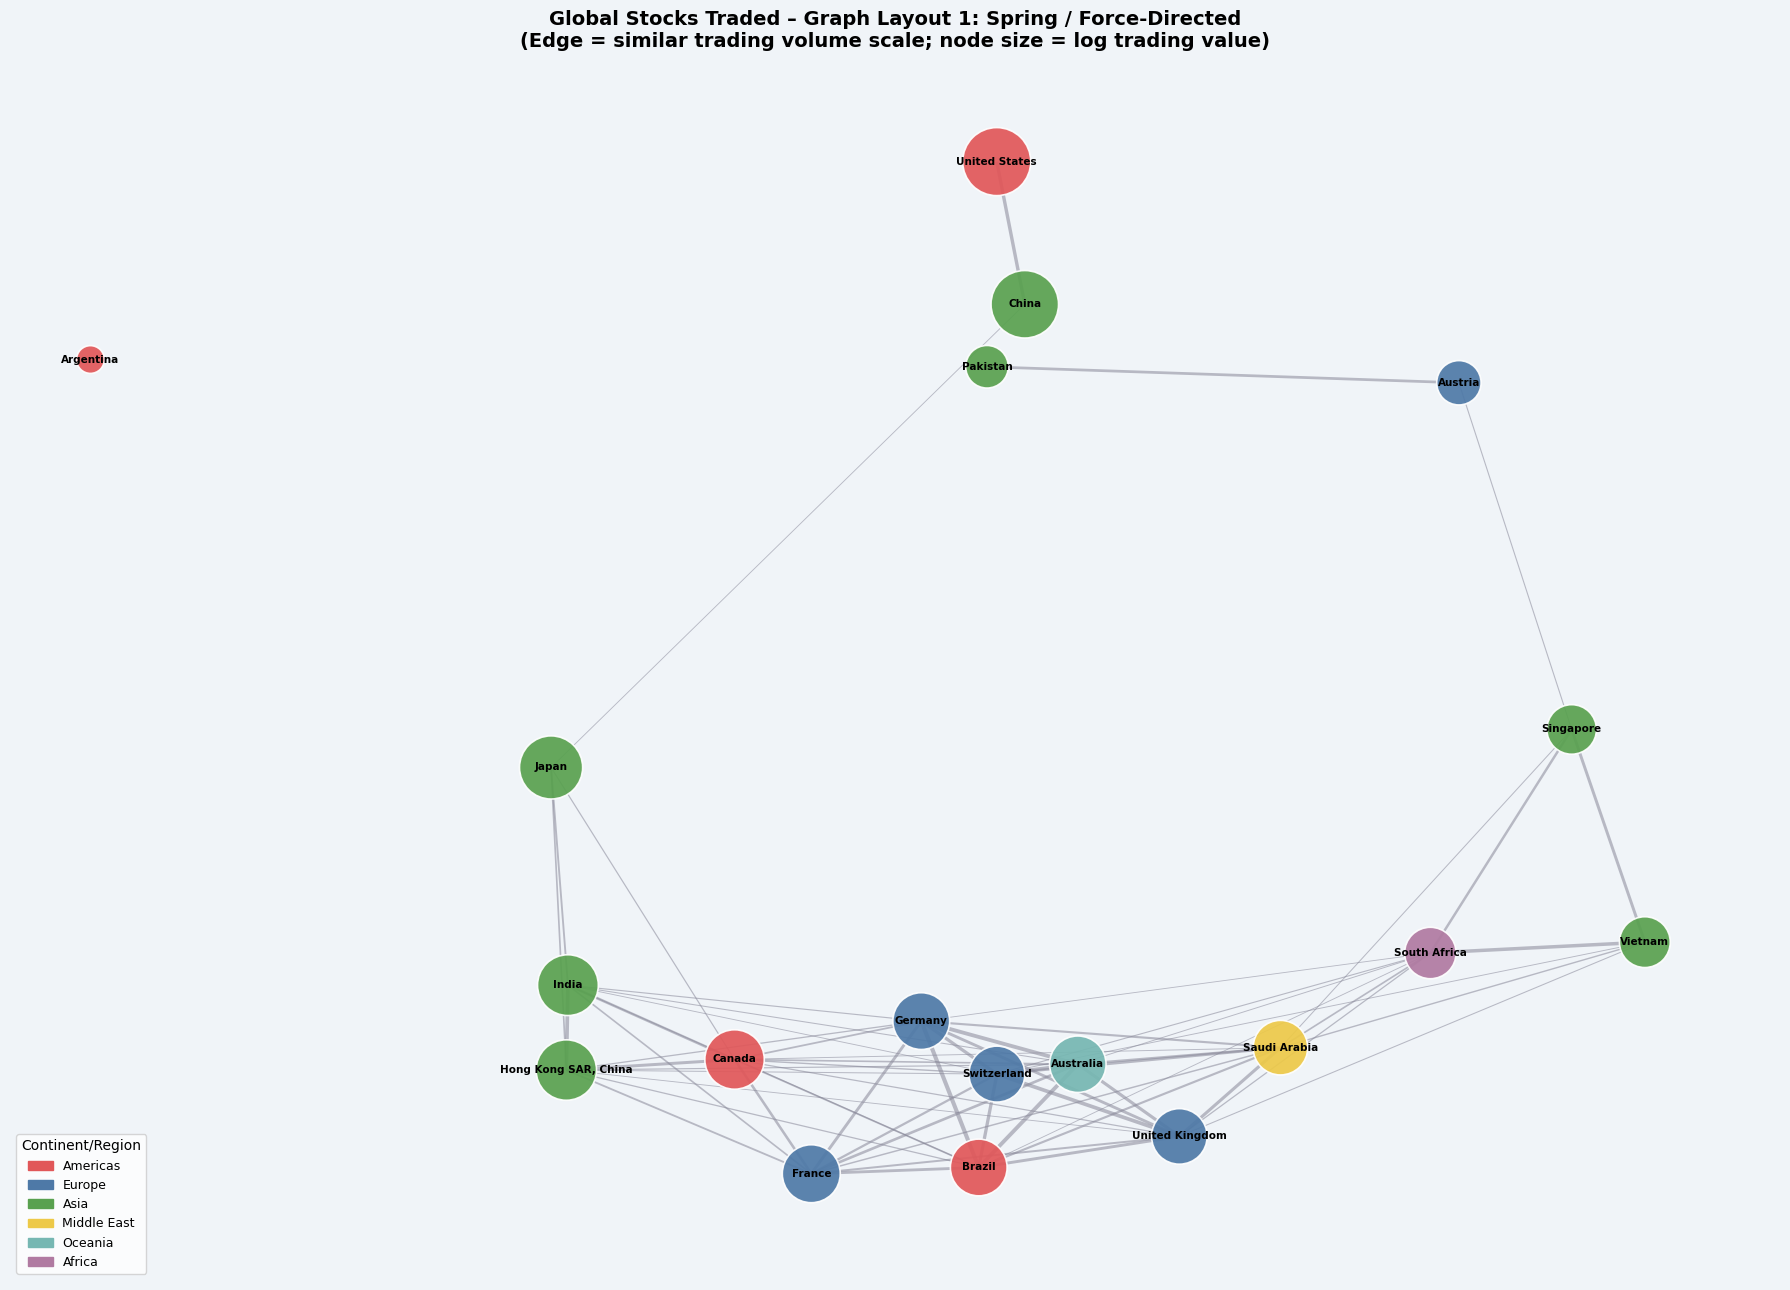

Saved: graph_layout1_spring.png


In [16]:
fig, ax = plt.subplots(figsize=(18, 13))
ax.set_facecolor('#F0F4F8')
fig.patch.set_facecolor('#F0F4F8')

pos_spring = nx.spring_layout(G, seed=7, k=2.2, weight='weight', iterations=200)

# Edges
nx.draw_networkx_edges(G, pos_spring, ax=ax,
                       width=edge_weights, edge_color='#888899',
                       alpha=0.55)

# Nodes
nx.draw_networkx_nodes(G, pos_spring, ax=ax,
                       node_color=node_colors_g, node_size=list(node_sizes),
                       edgecolors='white', linewidths=1.2, alpha=0.92)

# Labels
nx.draw_networkx_labels(G, pos_spring, ax=ax, font_size=7.5, font_weight='bold')

# Legend
lp = [mpatches.Patch(color=c, label=cont) for cont, c in CONT_COLOR.items()]
ax.legend(handles=lp, title='Continent/Region', fontsize=9, title_fontsize=10, loc='lower left')

ax.set_title('Global Stocks Traded – Graph Layout 1: Spring / Force-Directed\n'
             '(Edge = similar trading volume scale; node size = log trading value)',
             fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('graph_layout1_spring.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: graph_layout1_spring.png')

## 2.5 Graph Layout 2 – Circular Layout

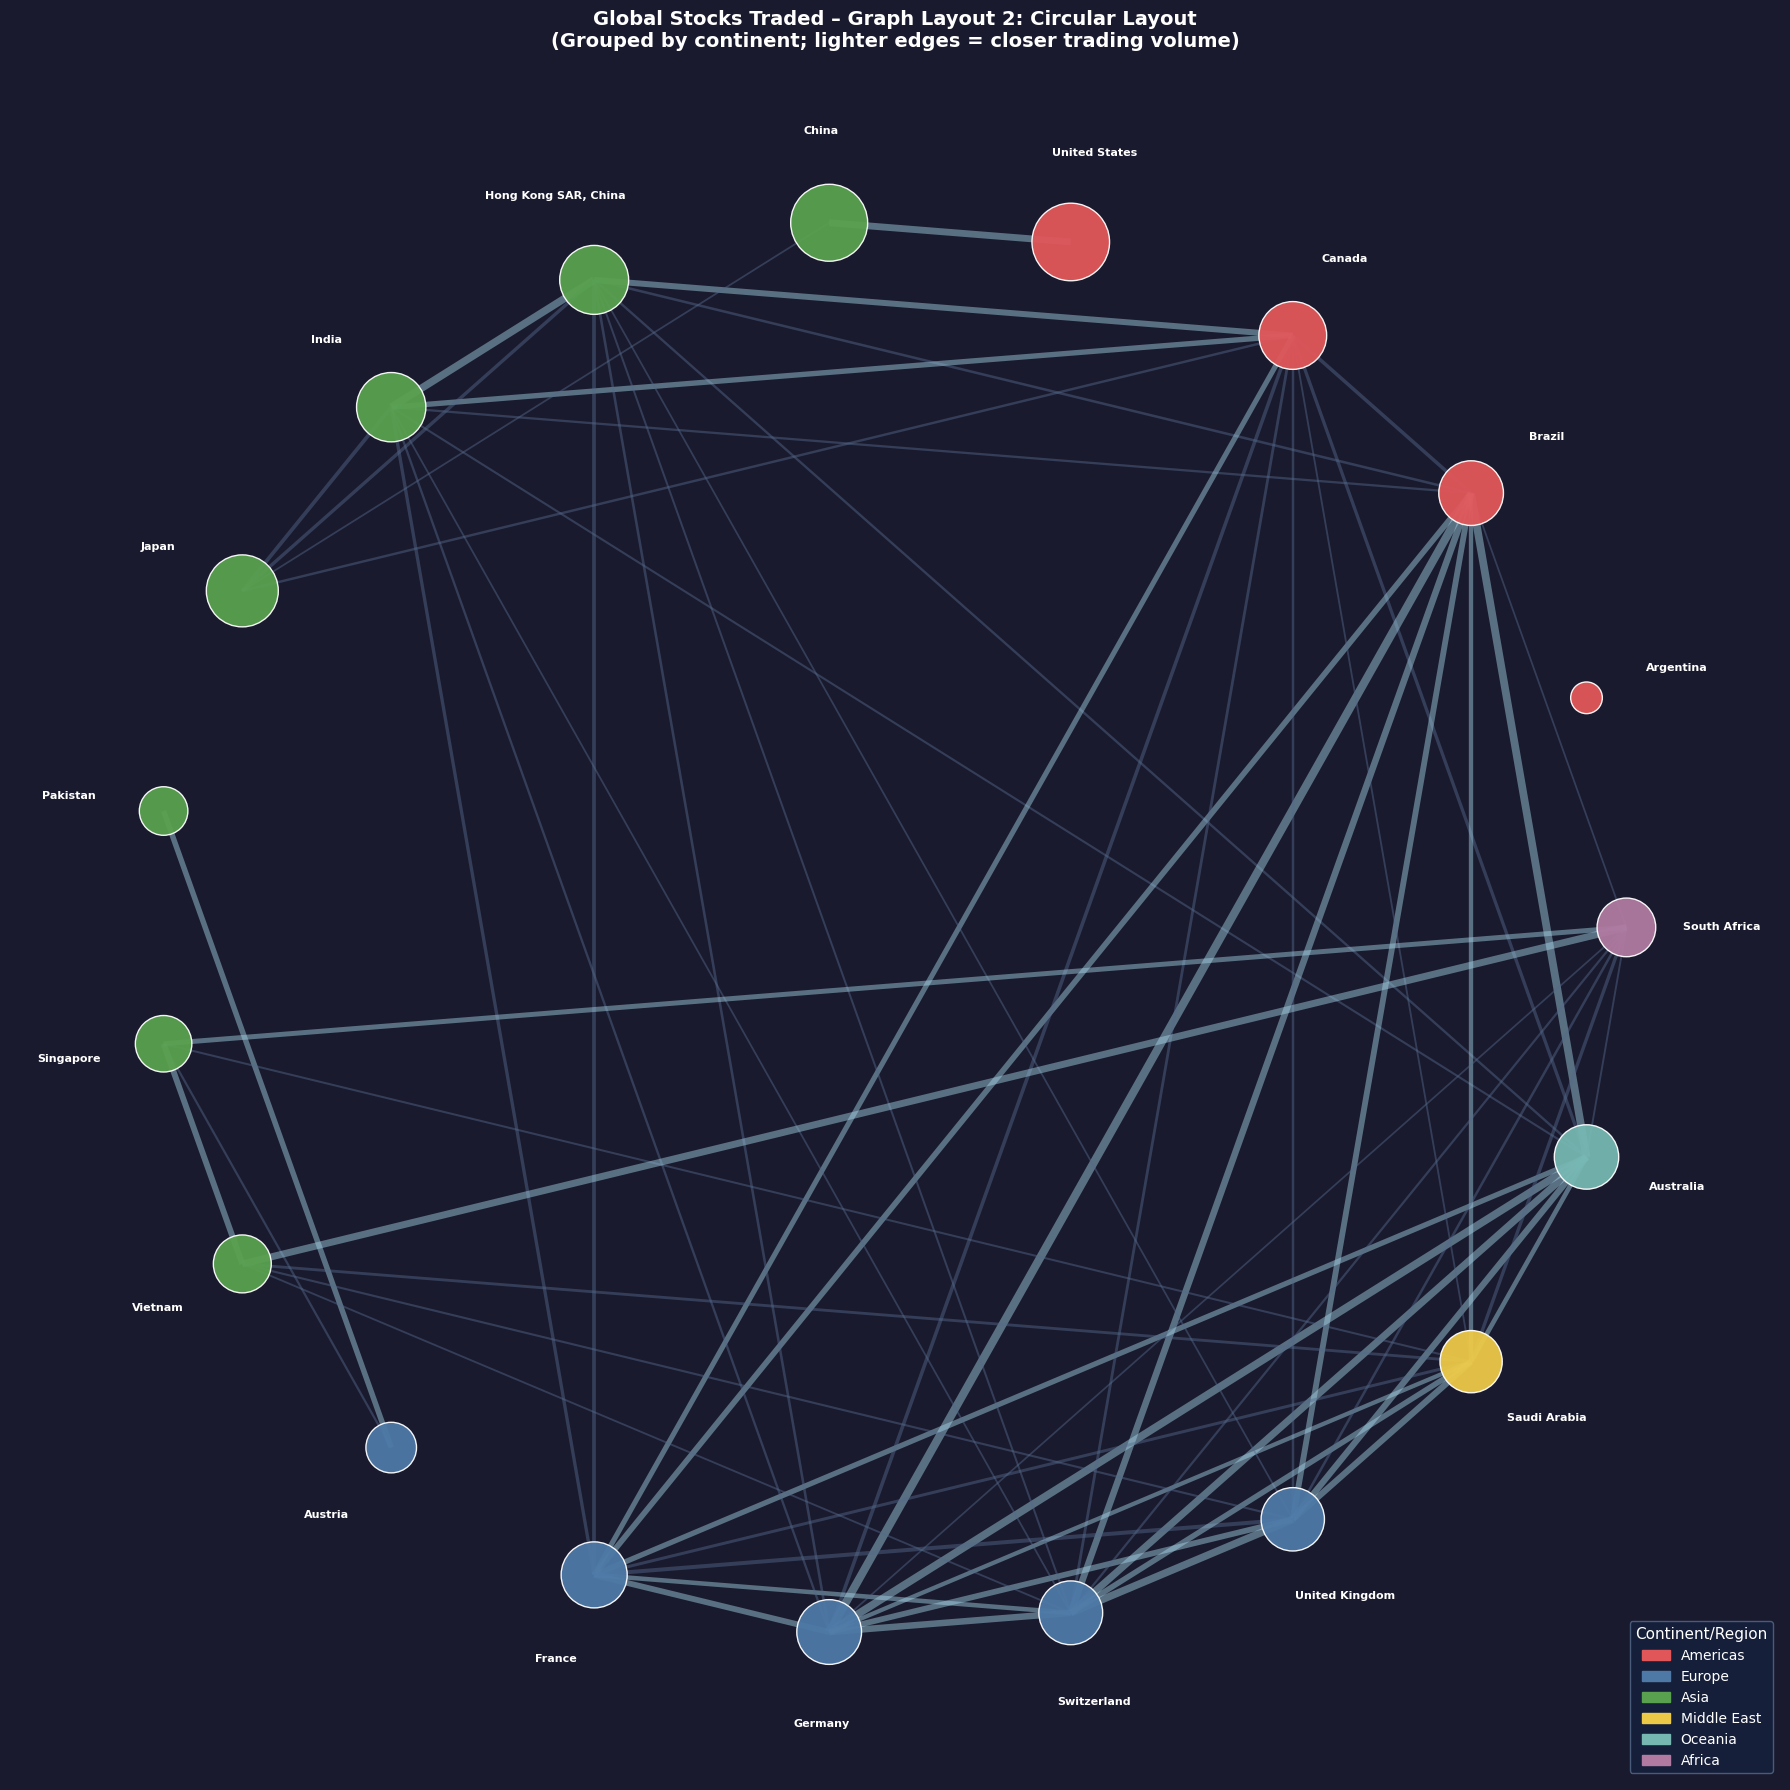

Saved: graph_layout2_circular.png


In [17]:
fig, ax = plt.subplots(figsize=(18, 18))
ax.set_facecolor('#1A1A2E')
fig.patch.set_facecolor('#1A1A2E')

# Sort nodes by continent for a cleaner circle
sorted_nodes = sorted(G.nodes(), key=lambda n: CONTINENT.get(n, 'ZZZ'))
pos_circ = nx.circular_layout(G, scale=1.5)

# Remap positions so nodes are sorted by continent around the circle
angles = np.linspace(0, 2 * np.pi, len(sorted_nodes), endpoint=False)
scale  = 1.5
pos_circ = {n: (scale * np.cos(a), scale * np.sin(a))
            for n, a in zip(sorted_nodes, angles)}

# Colour edges by how strong the similarity is
edge_colors_circ = ['#556B8C' if G[u][v]['weight'] < 0.5 else '#A8D8EA'
                    for u, v in G.edges()]

nx.draw_networkx_edges(G, pos_circ, ax=ax,
                       width=[w * 2 for w in edge_weights],
                       edge_color=edge_colors_circ,
                       alpha=0.45, style='solid')

nx.draw_networkx_nodes(G, pos_circ, ax=ax,
                       node_color=node_colors_g, node_size=list(node_sizes * 1.3),
                       edgecolors='white', linewidths=1.0, alpha=0.95)

# Label offset outward from circle centre
label_pos = {n: (x * 1.13, y * 1.13) for n, (x, y) in pos_circ.items()}
nx.draw_networkx_labels(G, label_pos, ax=ax,
                        font_size=8, font_weight='bold', font_color='white')

# Legend
lp_dark = [mpatches.Patch(color=c, label=cont) for cont, c in CONT_COLOR.items()]
leg2 = ax.legend(handles=lp_dark, title='Continent/Region',
                 fontsize=10, title_fontsize=11, loc='lower right',
                 facecolor='#16213E', edgecolor='#556B8C', labelcolor='white')
leg2.get_title().set_color('white')

ax.set_title('Global Stocks Traded – Graph Layout 2: Circular Layout\n'
             '(Grouped by continent; lighter edges = closer trading volume)',
             fontsize=14, fontweight='bold', color='white', pad=20)
ax.axis('off')
plt.tight_layout()
plt.savefig('graph_layout2_circular.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Saved: graph_layout2_circular.png')